# AcoustiGuard — Notebook 04: Vibration Model Training

This notebook trains a separate **Isolation Forest** model on vibration data (CWRU bearing dataset).
The trained model is saved as `vibration_model.pkl` and `vibration_scaler.pkl` alongside the existing audio models.

**Pipeline:**
1. Load CWRU `.mat` files (normal bearing data only)
2. Simulate MPU6050-style windows (ax, ay, az)
3. Extract statistical features per window
4. Train Isolation Forest (unsupervised — normal data only)
5. Evaluate on labeled fault data
6. Save model + scaler → `models/fan/<model_id>/vibration_model.pkl`

> **OR logic note:** At runtime, anomaly is flagged if *either* audio or vibration score is below threshold.
> This notebook focuses only on the vibration channel.

## 0. Imports & Config

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.io as sio
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), ".."))
CWRU_DIR    = os.path.join(BASE_DIR, "data", "raw", "cwru")
MODEL_ID    = "id_00"   # change to match your audio model id
MODEL_DIR   = os.path.join(BASE_DIR, "models", "fan", MODEL_ID)
OUTPUT_DIR  = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Vibration window settings (must match realtime_detection.py) ──────────────
WINDOW_SIZE    = 50     # number of MPU6050 readings per window (~0.5 s at 100 Hz)
STEP_SIZE      = 25     # 50% overlap between windows
CONTAMINATION  = 0.05   # expected anomaly fraction for Isolation Forest
RANDOM_STATE   = 42

print(f"BASE_DIR  : {BASE_DIR}")
print(f"CWRU_DIR  : {CWRU_DIR}")
print(f"MODEL_DIR : {MODEL_DIR}")

BASE_DIR  : c:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final
CWRU_DIR  : c:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\data\raw\cwru
MODEL_DIR : c:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\models\fan\id_00


## 1. Load CWRU Data

CWRU `.mat` files contain drive-end (DE) and fan-end (FE) accelerometer channels.
We treat DE data as our primary axis and synthesise ax/ay/az to mimic MPU6050 output.

Expected folder structure:
```
data/raw/cwru/
    normal/
        97.mat          # normal baseline, 0 hp load
        98.mat          # normal baseline, 1 hp
        99.mat          # normal baseline, 2 hp
        100.mat         # normal baseline, 3 hp
    fault/
        105.mat         # inner race fault 0.007"
        118.mat         # ball fault 0.007"
        130.mat         # outer race fault 0.007"
        # ... add more as needed
```
If you haven't downloaded the data yet, run `download_datasets.py` first.

In [2]:
def load_cwru_mat(filepath):
    """
    Load a CWRU .mat file and return the drive-end accelerometer signal.
    CWRU key names follow the pattern: X097_DE_time, X105_DE_time, etc.
    Returns a 1-D numpy array.
    """
    mat = sio.loadmat(filepath)
    # Find the drive-end (DE) key automatically
    de_keys = [k for k in mat.keys() if "DE_time" in k]
    if not de_keys:
        raise ValueError(f"No DE_time key found in {filepath}. Keys: {list(mat.keys())}")
    signal = mat[de_keys[0]].flatten()
    return signal


def signal_to_windows(signal, window_size=WINDOW_SIZE, step=STEP_SIZE):
    """
    Split a 1-D signal into overlapping windows.
    Each window simulates one batch of WINDOW_SIZE MPU6050 readings.
    Returns array of shape (n_windows, window_size).
    """
    windows = []
    for start in range(0, len(signal) - window_size, step):
        windows.append(signal[start : start + window_size])
    return np.array(windows)


def simulate_mpu6050(de_signal_windows):
    """
    CWRU has a single-axis accelerometer; MPU6050 gives 3 axes.
    Strategy:
      ax = DE channel (primary vibration axis)
      ay = ax * 0.3 + small noise  (cross-axis coupling estimate)
      az = gravity + small noise   (vertical axis ≈ 1g baseline)
    This preserves fault signatures in ax while making ay/az realistic.
    """
    np.random.seed(RANDOM_STATE)
    n, w = de_signal_windows.shape
    ax = de_signal_windows
    ay = ax * 0.3 + np.random.normal(0, 0.01, (n, w))
    az = np.ones((n, w)) + np.random.normal(0, 0.01, (n, w))  # ~1g gravity
    return ax, ay, az


# ── Load normal files ─────────────────────────────────────────────────────────
normal_dir = os.path.join(CWRU_DIR, "normal")
normal_signals = []

for fname in sorted(os.listdir(normal_dir)):
    if fname.endswith(".mat"):
        sig = load_cwru_mat(os.path.join(normal_dir, fname))
        normal_signals.append(sig)
        print(f"  Loaded normal: {fname}  → {len(sig):,} samples")

normal_signal_all = np.concatenate(normal_signals)
print(f"\nTotal normal samples: {len(normal_signal_all):,}")

# ── Load fault files ──────────────────────────────────────────────────────────
fault_dir = os.path.join(CWRU_DIR, "fault")
fault_signals = []

for fname in sorted(os.listdir(fault_dir)):
    if fname.endswith(".mat"):
        sig = load_cwru_mat(os.path.join(fault_dir, fname))
        fault_signals.append(sig)
        print(f"  Loaded fault:  {fname}  → {len(sig):,} samples")

fault_signal_all = np.concatenate(fault_signals)
print(f"Total fault samples: {len(fault_signal_all):,}")

  Loaded normal: 100.mat  → 485,643 samples
  Loaded normal: 97.mat  → 243,938 samples
  Loaded normal: 98.mat  → 483,903 samples
  Loaded normal: 99.mat  → 483,903 samples

Total normal samples: 1,697,387
  Loaded fault:  105.mat  → 121,265 samples
  Loaded fault:  109.mat  → 243,938 samples
  Loaded fault:  118.mat  → 122,571 samples
  Loaded fault:  122.mat  → 244,739 samples
  Loaded fault:  130.mat  → 121,991 samples
  Loaded fault:  135.mat  → 243,538 samples
  Loaded fault:  144.mat  → 122,281 samples
  Loaded fault:  156.mat  → 122,281 samples
  Loaded fault:  169.mat  → 121,846 samples
  Loaded fault:  185.mat  → 121,846 samples
Total fault samples: 1,586,296


## 2. Feature Extraction

For each window of 50 readings we extract **18 statistical features**:
mean, std, min, max, RMS, peak-to-peak — for each of ax, ay, az.

This matches exactly what `utils.extract_vibration_features()` does at runtime.

In [3]:
FEATURE_NAMES = [
    f"{axis}_{stat}"
    for axis in ["ax", "ay", "az"]
    for stat in ["mean", "std", "min", "max", "rms", "p2p"]
]

def extract_features_from_windows(ax_wins, ay_wins, az_wins):
    """
    Extract 18 features per window.
    Inputs: arrays of shape (n_windows, window_size)
    Returns: array of shape (n_windows, 18)
    """
    def window_stats(wins):
        rms = np.sqrt(np.mean(wins ** 2, axis=1))
        return np.column_stack([
            wins.mean(axis=1),
            wins.std(axis=1),
            wins.min(axis=1),
            wins.max(axis=1),
            rms,
            wins.max(axis=1) - wins.min(axis=1),   # peak-to-peak
        ])

    return np.hstack([
        window_stats(ax_wins),
        window_stats(ay_wins),
        window_stats(az_wins),
    ])


# ── Normal features ───────────────────────────────────────────────────────────
normal_windows = signal_to_windows(normal_signal_all)
ax_n, ay_n, az_n = simulate_mpu6050(normal_windows)
X_normal = extract_features_from_windows(ax_n, ay_n, az_n)
y_normal = np.zeros(len(X_normal))   # label 0 = normal

# ── Fault features ────────────────────────────────────────────────────────────
fault_windows = signal_to_windows(fault_signal_all)
ax_f, ay_f, az_f = simulate_mpu6050(fault_windows)
X_fault = extract_features_from_windows(ax_f, ay_f, az_f)
y_fault = np.ones(len(X_fault))      # label 1 = fault

print(f"Normal windows : {X_normal.shape}")
print(f"Fault windows  : {X_fault.shape}")
print(f"Feature names  : {FEATURE_NAMES}")

Normal windows : (67894, 18)
Fault windows  : (63450, 18)
Feature names  : ['ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ax_rms', 'ax_p2p', 'ay_mean', 'ay_std', 'ay_min', 'ay_max', 'ay_rms', 'ay_p2p', 'az_mean', 'az_std', 'az_min', 'az_max', 'az_rms', 'az_p2p']


## 3. EDA — Feature Distributions

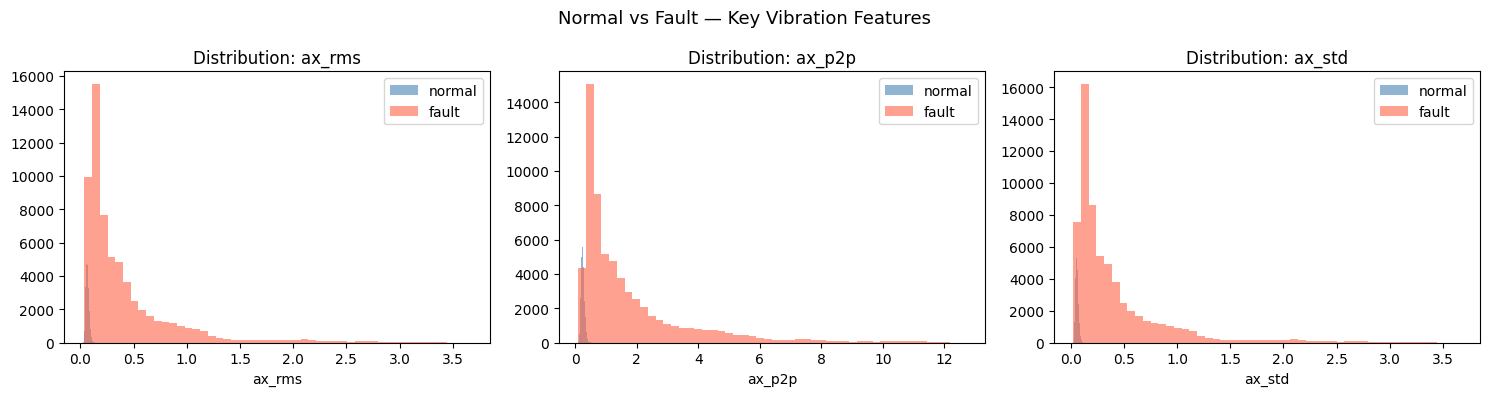

Saved: vibration_feature_distributions.png


In [4]:
df_normal = pd.DataFrame(X_normal, columns=FEATURE_NAMES)
df_normal["label"] = "normal"
df_fault  = pd.DataFrame(X_fault,  columns=FEATURE_NAMES)
df_fault["label"]  = "fault"
df_all = pd.concat([df_normal, df_fault], ignore_index=True)

# Plot ax RMS and az std — most discriminative for bearing faults
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
key_features = ["ax_rms", "ax_p2p", "ax_std"]

for ax_plot, feat in zip(axes, key_features):
    for label, color in [("normal", "steelblue"), ("fault", "tomato")]:
        subset = df_all[df_all["label"] == label][feat]
        ax_plot.hist(subset, bins=50, alpha=0.6, color=color, label=label)
    ax_plot.set_title(f"Distribution: {feat}")
    ax_plot.set_xlabel(feat)
    ax_plot.legend()

plt.suptitle("Normal vs Fault — Key Vibration Features", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "vibration_feature_distributions.png"), dpi=150)
plt.show()
print("Saved: vibration_feature_distributions.png")

## 4. Train Isolation Forest (Normal Data Only)

Isolation Forest is trained **exclusively on normal windows** — unsupervised.
Fault data is only used for evaluation in the next step.

In [5]:
# Scale features
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)

# Train
model = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model.fit(X_normal_scaled)
print("Isolation Forest trained on normal vibration data.")
print(f"  n_estimators : {model.n_estimators}")
print(f"  contamination: {model.contamination}")

Isolation Forest trained on normal vibration data.
  n_estimators : 200
  contamination: 0.05


## 5. Evaluate on Labeled Data

In [6]:
# Scale fault data with the SAME scaler (fit only on normal)
X_fault_scaled = scaler.transform(X_fault)

# Combine for evaluation
X_eval = np.vstack([X_normal_scaled, X_fault_scaled])
y_eval = np.concatenate([y_normal, y_fault])   # 0=normal, 1=fault

# Isolation Forest: predict returns 1 (normal) or -1 (anomaly)
y_pred_raw = model.predict(X_eval)
y_pred = (y_pred_raw == -1).astype(int)        # convert to 0/1

# Anomaly scores (lower = more anomalous)
scores = model.decision_function(X_eval)

print("=" * 50)
print("Classification Report")
print("=" * 50)
print(classification_report(y_eval, y_pred, target_names=["normal", "fault"]))

auc = roc_auc_score(y_eval, -scores)   # negate: lower score = more anomalous
print(f"ROC AUC: {auc:.4f}")

Classification Report
              precision    recall  f1-score   support

      normal       0.92      0.95      0.94     67894
       fault       0.94      0.91      0.93     63450

    accuracy                           0.93    131344
   macro avg       0.93      0.93      0.93    131344
weighted avg       0.93      0.93      0.93    131344

ROC AUC: 0.9686


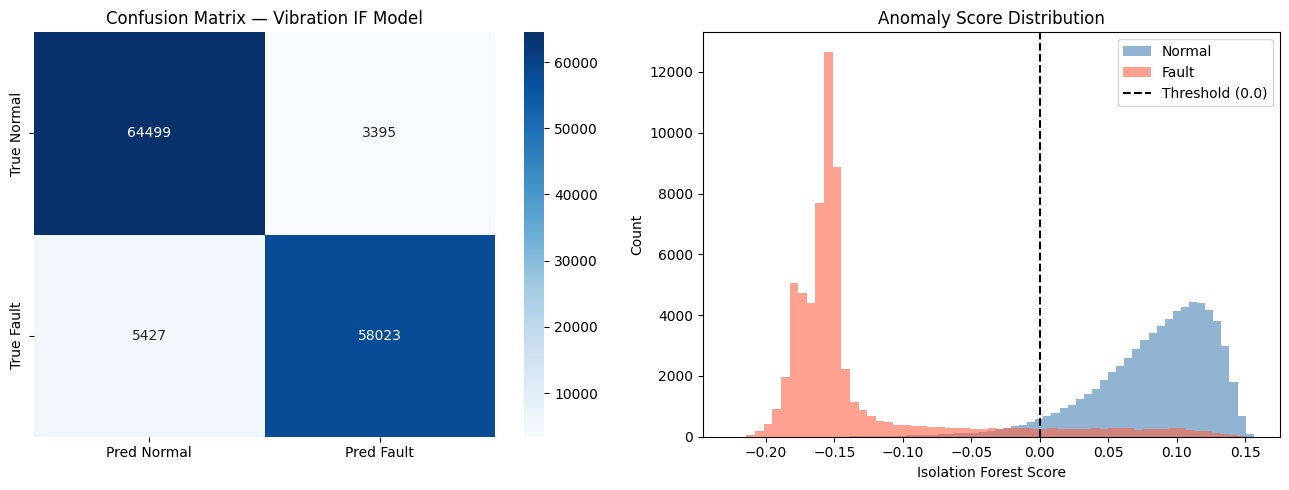

Saved: vibration_evaluation.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_eval, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Normal", "Pred Fault"],
    yticklabels=["True Normal", "True Fault"],
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix — Vibration IF Model")

# ── Anomaly Score Distribution ────────────────────────────────────────────────
axes[1].hist(scores[y_eval == 0], bins=60, alpha=0.6, color="steelblue", label="Normal")
axes[1].hist(scores[y_eval == 1], bins=60, alpha=0.6, color="tomato",    label="Fault")
axes[1].axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Threshold (0.0)")
axes[1].set_xlabel("Isolation Forest Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Anomaly Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "vibration_evaluation.png"), dpi=150)
plt.show()
print("Saved: vibration_evaluation.png")

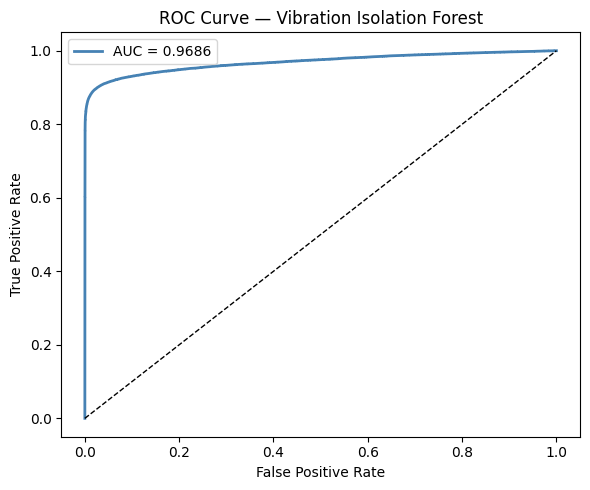

Saved: vibration_roc.png


In [8]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_eval, -scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Vibration Isolation Forest")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "vibration_roc.png"), dpi=150)
plt.show()
print("Saved: vibration_roc.png")

## 6. Threshold Tuning (Optional)

The default threshold is `0.0` (Isolation Forest convention).
If your false positive rate is too high or recall is too low, adjust below.
The chosen threshold must match `VIBRATION_THRESHOLD` in `src/config.py`.

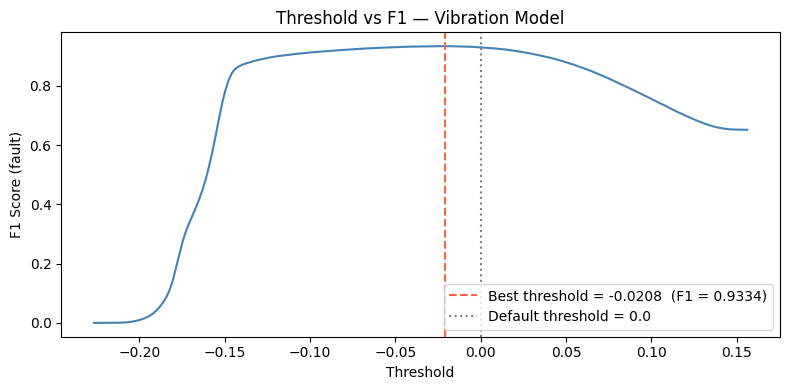


Default threshold (0.0) F1  : 0.9293
Best threshold (-0.0208) F1 : 0.9334

→ Update VIBRATION_THRESHOLD in src/config.py if you want to use best threshold.


In [9]:
# Try a range of thresholds and pick the one with best F1 on fault class
from sklearn.metrics import f1_score

threshold_candidates = np.linspace(scores.min(), scores.max(), 200)
f1_scores = []

for t in threshold_candidates:
    preds = (scores < t).astype(int)
    f1_scores.append(f1_score(y_eval, preds, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = threshold_candidates[best_idx]
best_f1 = f1_scores[best_idx]

plt.figure(figsize=(8, 4))
plt.plot(threshold_candidates, f1_scores, color="steelblue")
plt.axvline(x=best_threshold, color="tomato", linestyle="--",
            label=f"Best threshold = {best_threshold:.4f}  (F1 = {best_f1:.4f})")
plt.axvline(x=0.0, color="gray", linestyle=":", label="Default threshold = 0.0")
plt.xlabel("Threshold")
plt.ylabel("F1 Score (fault)")
plt.title("Threshold vs F1 — Vibration Model")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "vibration_threshold_tuning.png"), dpi=150)
plt.show()

print(f"\nDefault threshold (0.0) F1  : {f1_scores[np.argmin(np.abs(threshold_candidates))]:.4f}")
print(f"Best threshold ({best_threshold:.4f}) F1 : {best_f1:.4f}")
print(f"\n→ Update VIBRATION_THRESHOLD in src/config.py if you want to use best threshold.")

## 7. Save Model & Results

In [10]:
os.makedirs(MODEL_DIR, exist_ok=True)

# Save model and scaler
model_path  = os.path.join(MODEL_DIR, "vibration_model.pkl")
scaler_path = os.path.join(MODEL_DIR, "vibration_scaler.pkl")
joblib.dump(model,  model_path)
joblib.dump(scaler, scaler_path)
print(f"Saved: {model_path}")
print(f"Saved: {scaler_path}")

# Save results summary
y_pred_best = (scores < best_threshold).astype(int)
from sklearn.metrics import precision_score, recall_score

results = {
    "model": "IsolationForest",
    "channel": "vibration",
    "model_id": MODEL_ID,
    "n_estimators": model.n_estimators,
    "contamination": CONTAMINATION,
    "window_size": WINDOW_SIZE,
    "step_size": STEP_SIZE,
    "n_normal_windows": int(len(X_normal)),
    "n_fault_windows":  int(len(X_fault)),
    "roc_auc": round(auc, 4),
    "default_threshold": {
        "value": 0.0,
        "f1":        round(f1_score(y_eval, y_pred, zero_division=0), 4),
        "precision": round(precision_score(y_eval, y_pred, zero_division=0), 4),
        "recall":    round(recall_score(y_eval, y_pred, zero_division=0), 4),
    },
    "best_threshold": {
        "value":     round(float(best_threshold), 6),
        "f1":        round(best_f1, 4),
        "precision": round(precision_score(y_eval, y_pred_best, zero_division=0), 4),
        "recall":    round(recall_score(y_eval, y_pred_best, zero_division=0), 4),
    },
    "feature_names": FEATURE_NAMES
}

results_path = os.path.join(MODEL_DIR, "vibration_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved: {results_path}")

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"  ROC AUC            : {auc:.4f}")
print(f"  Default threshold  : 0.0  → F1 = {results['default_threshold']['f1']}")
print(f"  Best threshold     : {best_threshold:.4f} → F1 = {best_f1:.4f}")
print(f"  Model saved to     : {model_path}")

Saved: c:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\models\fan\id_00\vibration_model.pkl
Saved: c:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\models\fan\id_00\vibration_scaler.pkl
Saved: c:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\models\fan\id_00\vibration_results.json

SUMMARY
  ROC AUC            : 0.9686
  Default threshold  : 0.0  → F1 = 0.9293
  Best threshold     : -0.0208 → F1 = 0.9334
  Model saved to     : c:\Users\elifs\OneDrive\Masaüstü\acoustiguard_final\models\fan\id_00\vibration_model.pkl


## 8. Sanity Check — Simulate Runtime Inference

Verify the saved model produces correct output for a single window,
exactly as `inference.py` would call it at runtime on the Raspberry Pi.

In [11]:
# Reload from disk (confirm pickle round-trip works)
model_check  = joblib.load(model_path)
scaler_check = joblib.load(scaler_path)

# Simulate one normal window: list of dicts {ax, ay, az}
sample_window = [
    {"ax": float(ax_n[0, i]), "ay": float(ay_n[0, i]), "az": float(az_n[0, i])}
    for i in range(WINDOW_SIZE)
]

# Replicate utils.extract_vibration_features()
ax_arr = np.array([r["ax"] for r in sample_window])
ay_arr = np.array([r["ay"] for r in sample_window])
az_arr = np.array([r["az"] for r in sample_window])

def stats(arr):
    rms = np.sqrt(np.mean(arr ** 2))
    return [arr.mean(), arr.std(), arr.min(), arr.max(), rms, arr.max() - arr.min()]

feat = np.array(stats(ax_arr) + stats(ay_arr) + stats(az_arr)).reshape(1, -1)
feat_scaled = scaler_check.transform(feat)
score = model_check.decision_function(feat_scaled)[0]
is_anomaly = score < 0.0

print(f"Sample window score  : {score:.4f}")
print(f"Is anomaly (score<0) : {is_anomaly}")
print(f"Expected             : False  (window is from normal data)")
print("\nSanity check passed!" if not is_anomaly else "\nWarning: normal window flagged as anomaly — consider tuning contamination.")

Sample window score  : 0.1053
Is anomaly (score<0) : False
Expected             : False  (window is from normal data)

Sanity check passed!
